# Clasificación de vinos con redes neuronales



In [47]:
from sklearn.datasets import load_wine
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import random
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

In [48]:
# ejercicio 


df_wine = load_wine(as_frame=True)

X = df_wine.data
y = df_wine.target


In [49]:
display(X.describe())
display(X.info())
display(X.nunique()) #para ver categoricas
display(y.value_counts())

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: float64(13)
m

None

alcohol                         126
malic_acid                      133
ash                              79
alcalinity_of_ash                63
magnesium                        53
total_phenols                    97
flavanoids                      132
nonflavanoid_phenols             39
proanthocyanins                 101
color_intensity                 132
hue                              78
od280/od315_of_diluted_wines    122
proline                         121
dtype: int64

target
1    71
0    59
2    48
Name: count, dtype: int64

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
s = scaler.fit(X_train)
X_train_scaled = s.transform(X_train)
X_test_scaled = s.transform(X_test)

model = MLPClassifier(
    hidden_layer_sizes = (16,8),
    activation = 'tanh',
    solver = 'sgd',
    max_iter = 300,
    learning_rate_init = 0.01
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)



 accuracy: 0.9777777777777777


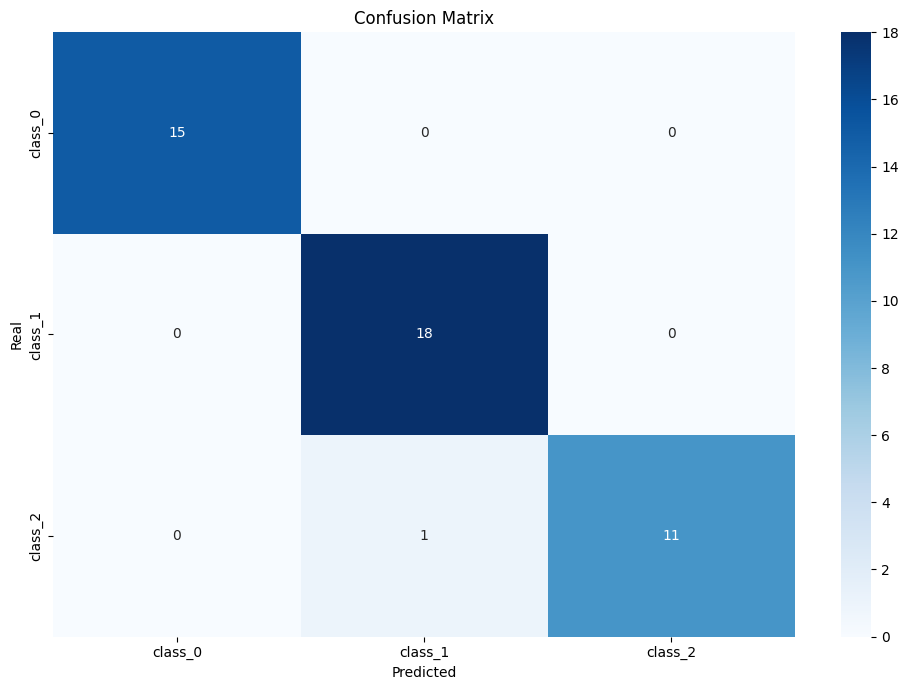

In [51]:
print(f" accuracy: {model.score(X_test_scaled, y_test)}")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (10,7))
sns.heatmap(cm, annot = True, fmt= 'd', cmap = 'Blues',
            xticklabels = df_wine.target_names,
            yticklabels = df_wine.target_names)
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


La cantidad de parametros optimizablesson:
- hidden_layers [16, 8]
- n_clases = 3
- n_features(imputs de la capa de entrada) = 13

entonces:
- Params capa 1: 13 * 16 + 16 (bias para cada neurona) = 208
- Params capa 2: 16 (salidas de capa 1) * 8 + 8 = 136
- Params capa 3: 8 (salidas de capa 2) * 3 (cantidad de clases) + 3 = 27

resultado = 224 + 136 + 27 = 387

# Ejercicio 2: Optimizacion de la arquitectura mediante algoritmo geneticos
Considerando hasta 3 capas ocultas. Buscar arquitectura que maximice el accuracy de validacion.
Complejidad es el numero de parámetros entrenables

Usamos N=13 atributos del datasets, solo optimizaremos la cantidad de parmetros (reduciendo la cantidad de capas)

**Representacion del cromosoma:**

Cada individuo de la poblacion representa una arquitectura (posible solucion).
- La primera capa esta siempre activa: su bit de activacion no forma parte del cromosoma y sus 7 bits codifican en binario sin signo el numero de neuronas de la capa
- Para la capa 2 y 3 el primer bit implica la activación o no de la capa. El resto de bits representa la cantidad de neuronas

**Funcion de aptitud**
Se deseará optimizar el accuracy promedio en una validación cruzada estratificada de 5 particiones sobre el conjunto de entrenamienot.



In [63]:
# ahora programamos la clase para el algoritmo genetico

class genetic_algorithm:
    def __init__(self, model_selection, model_cross, model_init):
        if model_selection == "ranking":
            self.f_selection = self._ranking
        elif  model_selection == "tournament":
            self.f_selection = self._tournament
        else: 
            raise ValueError("no")

        if model_cross == "unique":
            self.f_cross = self._unique_cross

        if model_init == "random":
            self.f_init = self._random_init
        
        self.population = []
        self.generational_fitness = []
        
    

    def run(self, n_init, p_cross, p_mutate,X_train, y_train, max_iters, beta):
        self.alpha = 1 - beta
        self.beta = beta
        # inicializamos la poblacion
        self.population = self.f_init(n_init)

        for chromosome in self.population:
            chromosome.fitness = self.fitness(chromosome, X_train, y_train)
        
        for generation in range(max_iters):
            new_population = []

            while len(new_population)< len(self.population):
                parent_1 = self.f_selection()
                parent_2 = self.f_selection()

                if random.random()<p_cross:
                    child_1, child_2 = self.f_cross(parent_1, parent_2)
                else:
                    #dejamos los padres
                    child_1 = MLPChromosome_genotype(binary_representation = parent_1.binary_representation)
                    child_2 = MLPChromosome_genotype(binary_representation = parent_2.binary_representation)
                
                #una vez tenido los hijos mutamos y corregimos
                if random.random() < p_mutate:
                    child_1.mutate()
                
                if random.random() < p_mutate:
                    child_2.mutate()
                
                child_1.fitness = self.fitness(child_1, X_train, y_train)
                child_2.fitness = self.fitness(child_2, X_train, y_train)

                new_population.append(child_1)
                if len(new_population) < len(self.population):
                    new_population.append(child_2) #por si la poblacion es impar

                # recalculamos fitness de toda la nueva poblacion

            for chromosome in new_population:
                chromosome.fitness = self.fitness(
                    chromosome,
                    X_train,
                    y_train
                )

            avg_fitness = np.mean([chromosome.fitness for chromosome in new_population])
                # guardamos historial
            self.generational_fitness.append(avg_fitness)
            #reemplazo generacional a priori
            self.population = new_population
        best_chromosome = max(self.population, key=lambda chromosome: chromosome.fitness)

        return best_chromosome

    def fitness(self, chromosome, X_train, y_train, max_params = 35203):
        layers = chromosome.decode()

        #eliminar capas Nones
        hidden_layers = tuple(layer for layer in layers if layer is not None)

        model = MLPClassifier(hidden_layer_sizes = hidden_layers, max_iter = 300, early_stopping = True, random_state = 42, n_iter_no_change = 10, validation_fraction = 0.1)
        cv = StratifiedKFold(n_splits=5, shuffle = True, random_state = 42)
        scores = cross_val_score(model, X_train, y_train, cv = cv, scoring = "accuracy")

        accuracy_cv = np.mean(scores)
        input_dim = X_train.shape[1]
        output_dim = len(np.unique(y_train))

        architecture = [input_dim] + list(hidden_layers) + [output_dim] #lista con todo
        n_params =0

        for i in range(len(architecture)-1):
            n_in = architecture[i]
            n_out = architecture[i+1]
            # pesos + bias
            n_params += (n_in + 1) * n_out

        compactness = 1 - (n_params / max_params)
        fit = self.alpha * accuracy_cv + self.beta *compactness

        return fit

    def _tournament(self, k=3):
        candidates = random.sample(self.population, k)
        winner = max(candidates,key=lambda chromosome: chromosome.fitness)

        return winner

    def _ranking(self):
        pass

    def _unique_cross(self, parent_1, parent_2):
    
        p1 = parent_1.binary_representation
        p2 = parent_2.binary_representation

        layer1_p1 = p1[0:7]
        layer1_p2 = p2[0:7]

        child1_layer1 = layer1_p1[:3] + layer1_p2[3:]
        child2_layer1 = layer1_p2[:3] + layer1_p1[3:]

        a2_child1 = p1[7] #conservamos del padre "principal"
        a2_child2 = p2[7]

        layer2_p1 = p1[8:15]
        layer2_p2 = p2[8:15]

        child1_layer2 = layer2_p1[:3] + layer2_p2[3:]
        child2_layer2 = layer2_p2[:3] + layer2_p1[3:]

        a3_child1 = p1[15]
        a3_child2 = p2[15]

        layer3_p1 = p1[16:23]
        layer3_p2 = p2[16:23]

        child1_layer3 = layer3_p1[:3] + layer3_p2[3:]
        child2_layer3 = layer3_p2[:3] + layer3_p1[3:]

        
        child1_bits = (child1_layer1 + a2_child1 + child1_layer2 + a3_child1 + child1_layer3) #hijo 1
        child2_bits = (child2_layer1 + a2_child2 + child2_layer2 +a3_child2 + child2_layer3) #hijo 2

        child1 = MLPChromosome_genotype(binary_representation=child1_bits)
        child2 = MLPChromosome_genotype(binary_representation=child2_bits)
        return child1, child2

    def _random_init(self, n_init):
        self.population = []
        for _ in range(n_init):
            h1 = random.randint(1, 128)
            h2 = random.randint(1, 128)
            h3 = random.randint(1, 128)

            chromosome = MLPChromosome_genotype(hidden_layer_sizes=(h1, h2, h3))
            self.population.append(chromosome)
        return self.population


    



# ejercicio 2:


In [ ]:
betas = [0, 0.1, 0.3, 0.5]

results = {}

best_global_fitness = -np.inf
best_global_beta = None
best_global_chromosome = None


for beta in betas:

    print("="*50)
    print(f"Ejecutando AG con beta = {beta}")
    print("="*50)

    ga = genetic_algorithm(
        model_selection="tournament",
        model_cross="unique",
        model_init="random"
    )

    # ejecutamos AG
    best_chromosome = ga.run(
        n_init=30,
        p_cross=0.8,
        p_mutate=0.1,
        X_train=X_train_scaled,
        y_train=y_train,
        max_iters=100,
        beta=beta
    )

    # guardamos resultados
    results[beta] = {
        "fitness_history": ga.generational_fitness,
        "best_chromosome": best_chromosome,
        "best_fitness": best_chromosome.fitness
    }

    print("\nMejor cromosoma:")
    print(best_chromosome)

    print("\nArquitectura:")
    print(best_chromosome.decode())

    print("\nFitness:")
    print(best_chromosome.fitness)

    # actualizamos mejor global
    if best_chromosome.fitness > best_global_fitness:
        best_global_fitness = best_chromosome.fitness
        best_global_beta = beta
        best_global_chromosome = best_chromosome

Ejecutando AG con beta = 0


c:\Users\nadador frustrado\Desktop\git\4to\metaherusiticas\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


In [ ]:
print("================================")
print("MEJOR SOLUCION GLOBAL")
print("================================")

print("Beta:")
print(best_global_beta)

print("\nCromosoma:")
print(best_global_chromosome)

print("\nArquitectura:")
print(best_global_chromosome.decode())

print("\nFitness:")
print(best_global_chromosome.fitness)

best_history = results[best_global_beta]["fitness_history"]
plt.figure(figsize=(10,6))
plt.plot(best_history)
plt.xlabel("Generacion")
plt.ylabel("Fitness promedio")
plt.title(
    f"Evolucion del Fitness Generacional\n"
    f"Mejor beta = {best_global_beta}"
)
plt.grid(True)
plt.show()




In [ ]:
# decodificamos arquitectura

layers = best_global_chromosome.decode()

hidden_layers = tuple(
    layer for layer in layers
    if layer is not None
)

print(hidden_layers)

scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)


final_model = MLPClassifier(
    hidden_layer_sizes=hidden_layers,
    max_iter=300,
    early_stopping=True,
    random_state=42
)

final_model.fit(X_scaled, y)